# Feature Extraction and Price Prediction for Mobile Phones
## Objective
#### 1. Build a machine learning model that can predict the price of a mobile phone based on its specifications.
#### 2. Understand which features (RAM, storage, camera, battery, processor, screen size, etc.) have the greatest impact on mobile phone prices.
#### 3. Help businesses make data-driven decisions regarding product design, pricing, and market positioning.

## Tools used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- 
## Algorithms:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Model Evaluation
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score


In [298]:
# Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [299]:
# load the dataset
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\Processed_Flipdata - Processed_Flipdata.csv")

### Data Understanding

In [300]:
df.shape
# There are 541 rows and 12 columns

(541, 12)

In [301]:
df.isnull().sum()
# There is no missing value

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [302]:
df.duplicated().sum()
# There is no duplicate value

np.int64(0)

In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


In [304]:
df.dtypes

Unnamed: 0         int64
Model             object
Colour            object
Memory             int64
RAM                int64
Battery_           int64
Rear Camera       object
Front Camera      object
AI Lens            int64
Mobile Height    float64
Processor_        object
Prize             object
dtype: object

In [305]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000


### Data cleaning

In [306]:
# Remove unwanted columns
df.drop("Unnamed: 0",axis=1,inplace=True)

In [307]:
df.shape

(541, 11)

In [308]:
# convert obj into int
df["Prize"]=df["Prize"].str.replace(",","",regex=False).astype(int)

<Axes: ylabel='Prize'>

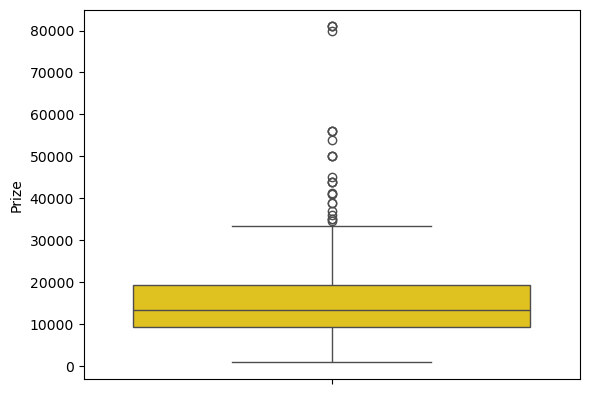

In [309]:
# Outlier Detection
sns.boxplot(df["Prize"],color="gold")

In [310]:
df["Prize"].describe()

count      541.000000
mean     16228.375231
std      10793.588322
min        920.000000
25%       9290.000000
50%      13499.000000
75%      19280.000000
max      80999.000000
Name: Prize, dtype: float64

In [311]:
Q1 = df["Prize"].quantile(0.25)
Q3 = df["Prize"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[df["Prize"] > upper_bound]

print("Number of outliers",len(outliers))

Number of outliers 25


<Axes: ylabel='RAM'>

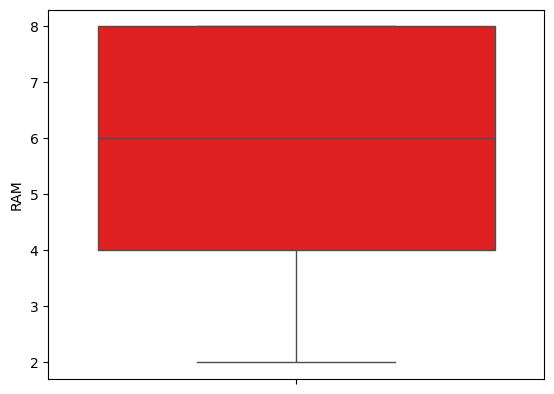

In [312]:
sns.boxplot(df["RAM"],color="Red")

#### No outliers detected in RAM column.

<Axes: ylabel='Memory'>

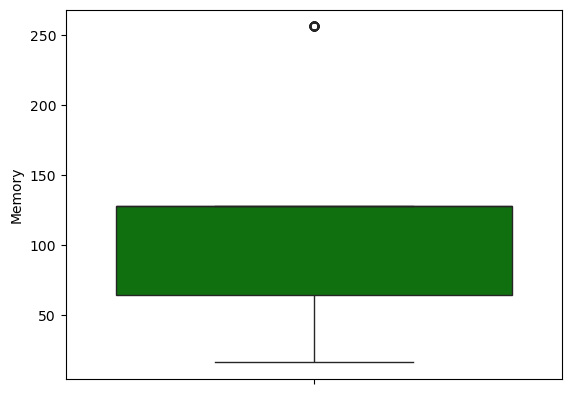

In [313]:
sns.boxplot(df["Memory"],color="Green")

In [314]:
Q1=df["Memory"].quantile(0.25)
Q3=df["Memory"].quantile(0.75)
IQR=Q3-Q1
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR
Outliers=df[df["Memory"]>Upper_bound]
print("Number of Outliers",len(Outliers))

Number of Outliers 55


<Axes: ylabel='Battery_'>

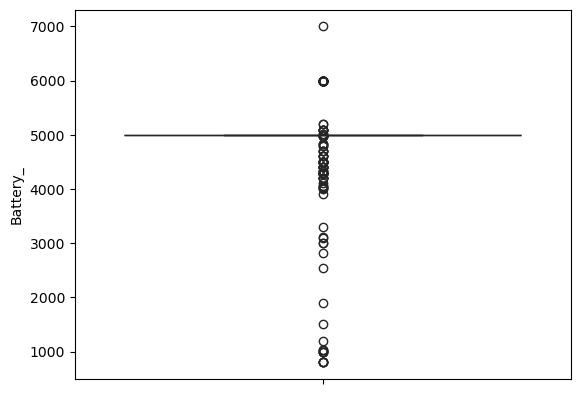

In [315]:
sns.boxplot(df["Battery_"],color="Green")

In [316]:
Q1=df["Battery_"].quantile(0.25)
Q3=df["Battery_"].quantile(0.75)
IQR=Q3-Q1
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR
Outliers=df[df["Battery_"]>Upper_bound]
print("Number of Outliers",len(Outliers))

Number of Outliers 53


In [317]:
Q1=df['Memory'].quantile(0.25)
Q3=df['Memory'].quantile(0.75)
IQR=Q3-Q1
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR
Outliers=df[df['Memory']>Upper_bound]
print("Number of Outliers",len(Outliers))

Number of Outliers 55


### Outlier Analysis

#### Boxplots were used to identify potential outliers in numerical features such as Price, RAM, and Battery.
    
#### The IQR method detected 25 outliers in Price, 55 outliers in RAM,55 outliers on Memory and 53 outliers in Battery.
#### After further investigation, these observations were found to represent genuine variations in mobile phone specifications
#### and market prices rather than data entry errors. 
#### Therefore, the outliers were retained to preserve important business information and 
#### ensure the model captures real-world pricing behavior.

# Exploratory Data Analysis (EDA)

## Univariate Analysis

Price Skewness: 2.4255791831830114


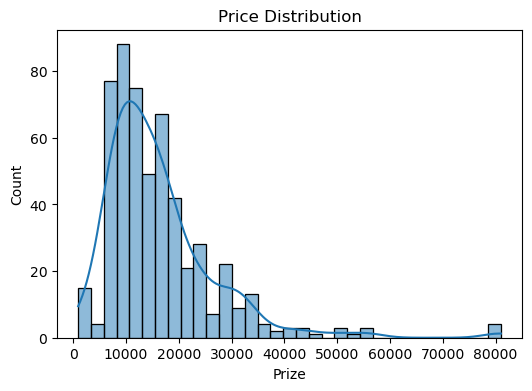

In [318]:
# Price Disribution
print("Price Skewness:", df['Prize'].skew())

plt.figure(figsize=(6,4))
sns.histplot(df['Prize'], kde=True)
plt.title('Price Distribution')
plt.show()

### Insight:

 The Price distribution is highly right-skewed, indicating that most mobile phones belong to the budget and mid-range segments, 
 while a small number of premium smartphones are priced significantly higher.
 This suggests the presence of a few expensive flagship devices in the dataset.

RAM Skewness: 0.06761693421839213


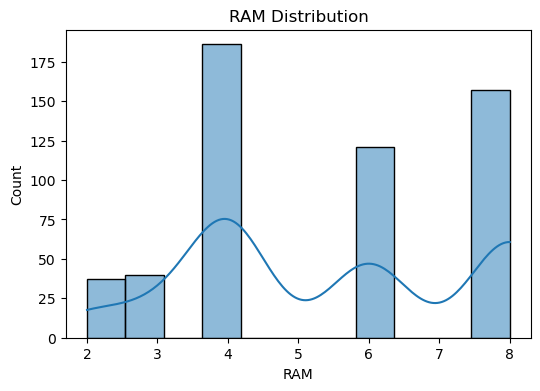

In [319]:
# RAM Distribution
print("RAM Skewness:", df['RAM'].skew())

plt.figure(figsize=(6,4))
sns.histplot(df['RAM'], kde=True)
plt.title('RAM Distribution')
plt.show()

### Insight:

 The RAM distribution is nearly symmetric, indicating a balanced representation of different RAM configurations.  Most devices are evenly distributed across common RAM variants, making RAM a stable feature for analysis and model building.

Battery Skewness: -3.3042495558784655


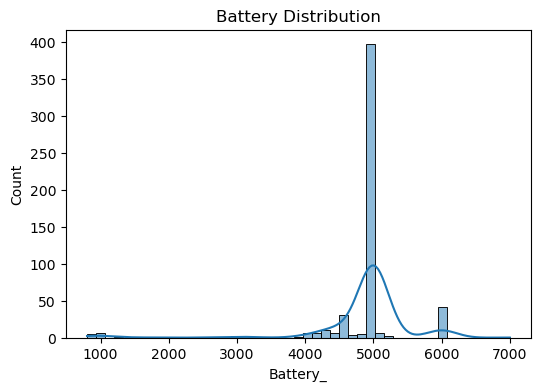

In [320]:
# Battery Distribution
print("Battery Skewness:", df['Battery_'].skew())

plt.figure(figsize=(6,4))
sns.histplot(df['Battery_'], kde=True)
plt.title('Battery Distribution')
plt.show()

### Insight:
 The Battery distribution is highly left-skewed, indicating that a large proportion of smartphones have higher battery capacities
(primarily around 5000 mAh), while only a few devices have lower battery capacities. 
 This reflects the industry trend toward larger batteries in modern smartphones.

Memory Skewness: 1.0297044017064259


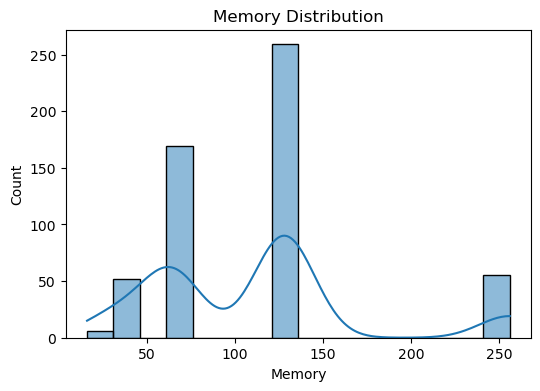

In [321]:
# Memory Distribution
print("Memory Skewness:", df['Memory'].skew())

plt.figure(figsize=(6,4))
sns.histplot(df['Memory'], kde=True)
plt.title('Memory Distribution')
plt.show()

### Insight:

The Memory distribution is right-skewed, suggesting that most smartphones are equipped with standard storage options such as 64 GB and 128 GB, while fewer devices offer higher storage capacities like 256 GB and 512 GB.

## Bivariate Analysis

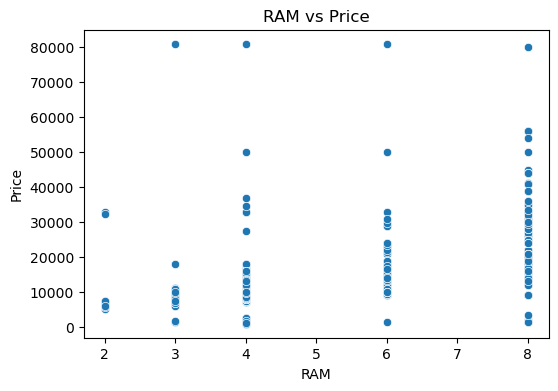

In [322]:
# RAM vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='RAM', y='Prize', data=df)

plt.title('RAM vs Price')
plt.xlabel('RAM')
plt.ylabel('Price')
plt.show()

In [323]:
df[['RAM','Prize']].corr()

,RAM,Prize
RAM,1.000000,0.532024
Prize,0.532024,1.000000


### Insight: 
RAM has a moderate positive correlation (0.53) with Price. The scatter plot shows that higher RAM phones are generally more expensive, but the wide spread of prices within the same RAM category indicates that other features also play an important role in determining smartphone prices.

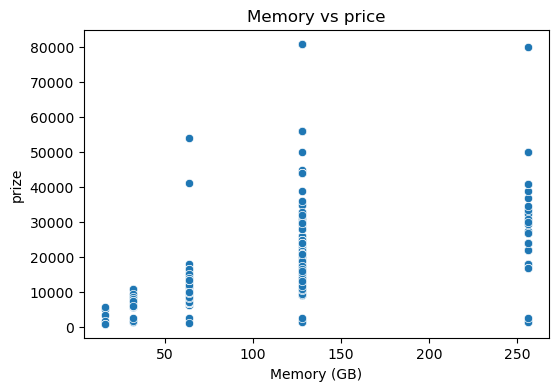

In [324]:
# Memory vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x="Memory", y="Prize", data=df)
plt.title("Memory vs price")
plt.xlabel("Memory (GB)")
plt.ylabel("prize")
plt.show()

In [325]:
df[['Memory','Prize']].corr()

,Memory,Prize
Memory,1.00000,0.56666
Prize,0.56666,1.00000


### Insight:
The scatter plot shows a positive relationship between Memory and Price. As the storage capacity increases, the price of smartphones generally tends to increase. The correlation coefficient of 0.56666 indicates a moderate positive relationship, suggesting that Memory is an important factor influencing smartphone pricing, although it is not the sole determinant of price.

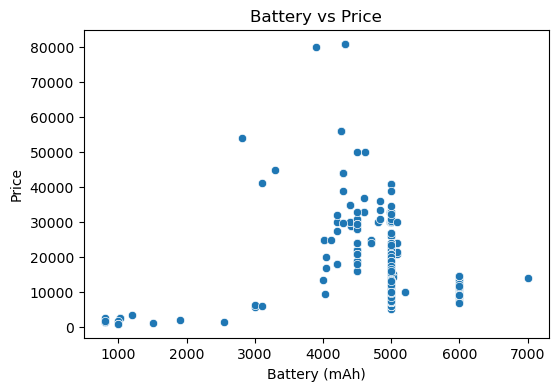

In [326]:
#  Battery vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='Battery_', y='Prize', data=df)

plt.title('Battery vs Price')
plt.xlabel('Battery (mAh)')
plt.ylabel('Price')
plt.show()

In [327]:
df[['Battery_','Prize']].corr()

,Battery_,Prize
Battery_,1.000000,-0.034297
Prize,-0.034297,1.000000


### Insight:
The correlation between Battery and Price is -0.034, indicating a negligible relationship between the two variables. This suggests that battery capacity has little to no influence on smartphone pricing. Smartphones across different price segments often offer similar battery capacities, making Battery a weak predictor of Price.


### Overall Insight of Bivariate Analysis:

Memory and RAM show a meaningful positive relationship with smartphone prices, indicating that higher performance and storage specifications generally lead to higher prices. In contrast, Battery capacity exhibits virtually no relationship with Price, suggesting that it is not a key factor in determining smartphone pricing.

## Multivariate Analysis

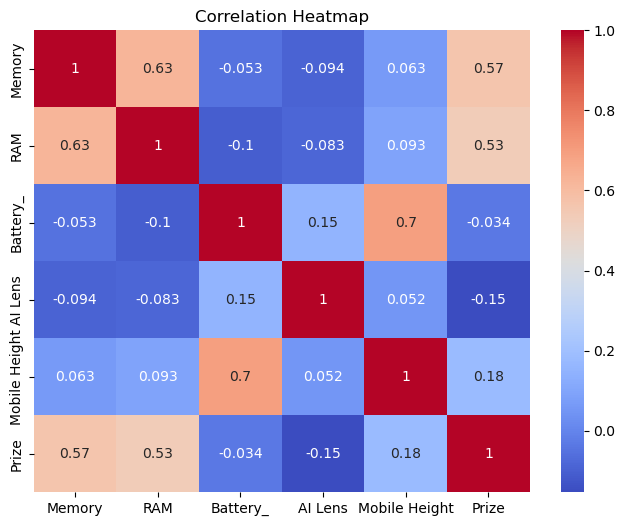

In [328]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
annot=True,
cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight: 
The heatmap shows that Memory and RAM are the most influential features for smartphone pricing, while Battery and AI Lens have minimal impact. Additionally, no severe multicollinearity was detected among the independent variables.

## Feature Engineering

### Observation:
Feature engineering was performed by creating Total_Camera and RAM_Memory features. These engineered features improved the model's ability to capture relationships between smartphone specifications and price.

In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Colour         541 non-null    object 
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    object 
 6   Front Camera   541 non-null    object 
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    object 
 10  Prize          541 non-null    int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 46.6+ KB


In [330]:
# convert obj into int
df['Front Camera']=df['Front Camera'].str.replace('MP','',regex=False).astype(int)

In [331]:
# convert int into obj
df['Rear Camera']=df['Rear Camera'].str.replace('MP','',regex=False).astype(int)

In [332]:
# Add Rear camera and front camera columns into siingle Total_camera column
df["Total_camera"]=df["Rear Camera"] + df["Front Camera"]

In [333]:
df["Total_camera"]

0      18
1      18
2      66
3      13
4      55
       ..
536    62
537     7
538    58
539    82
540    58
Name: Total_camera, Length: 541, dtype: int64

In [334]:
## RAM × Memory Score

In [335]:
df["RAM_Memory"]=df["RAM"] * df["Memory"]

In [336]:
df["RAM_Memory"]

0       256
1       256
2      1024
3        64
4      1024
       ... 
536    2048
537      64
538     256
539    1024
540     512
Name: RAM_Memory, Length: 541, dtype: int64

In [337]:
## Check Correlation between Price and Total_camera
df[["Total_camera","Prize"]].corr()

,Total_camera,Prize
Total_camera,1.000000,0.481157
Prize,0.481157,1.000000


In [338]:
## check correlation between price and RAM_Memory
df[['RAM_Memory', 'Prize']].corr()

,RAM_Memory,Prize
RAM_Memory,1.000000,0.568485
Prize,0.568485,1.000000


### Feature Engineering Observation

Two new features were created: Total_Camera and RAM_Memory. Correlation analysis showed that Total_Camera has a moderate positive relationship with Price (0.48), while RAM_Memory has a correlation of 0.57. These results indicate that camera quality, storage, and performance specifications contribute to smartphone pricing. However, RAM_Memory provides only a marginal improvement over the original Memory feature.

## Machine Learning phase

### Encode Categorical Columns 

In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Colour         541 non-null    object 
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    int64  
 6   Front Camera   541 non-null    int64  
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    object 
 10  Prize          541 non-null    int64  
 11  Total_camera   541 non-null    int64  
 12  RAM_Memory     541 non-null    int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 55.1+ KB


### Dummy variable creation

In [340]:
print(dfNew.columns)

Index(['Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens',
       'Mobile Height', 'Prize', 'Total_camera', 'RAM_Memory', 'Brand_Google',
       'Brand_I', 'Brand_IQOO', 'Brand_Infinix', 'Brand_LAVA',
       'Brand_MOTOROLA', 'Brand_Micromax', 'Brand_Nokia', 'Brand_OPPO',
       'Brand_OnePlus', 'Brand_POCO', 'Brand_REDMI', 'Brand_Redmi',
       'Brand_SAMSUNG', 'Brand_Tecno', 'Brand_itel', 'Brand_micromax',
       'Brand_micromax1', 'Brand_nothing', 'Brand_realme', 'Brand_redmi',
       'Brand_vivo'],
      dtype='object')


In [341]:
df['Brand'] = df['Model'].str.split().str[0]

In [342]:
df.drop(['Model', 'Colour', 'Processor_'], axis=1, inplace=True)

In [343]:
dfNew = pd.get_dummies(df, columns=['Brand'], drop_first=True)

In [344]:
dfNew.shape

(541, 32)

In [345]:
### Convert all data types into int only
dfNew=dfNew.astype("float")

In [346]:
dfNew.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Memory           541 non-null    float64
 1   RAM              541 non-null    float64
 2   Battery_         541 non-null    float64
 3   Rear Camera      541 non-null    float64
 4   Front Camera     541 non-null    float64
 5   AI Lens          541 non-null    float64
 6   Mobile Height    541 non-null    float64
 7   Prize            541 non-null    float64
 8   Total_camera     541 non-null    float64
 9   RAM_Memory       541 non-null    float64
 10  Brand_Google     541 non-null    float64
 11  Brand_I          541 non-null    float64
 12  Brand_IQOO       541 non-null    float64
 13  Brand_Infinix    541 non-null    float64
 14  Brand_LAVA       541 non-null    float64
 15  Brand_MOTOROLA   541 non-null    float64
 16  Brand_Micromax   541 non-null    float64
 17  Brand_Nokia     

### Insight:
The dataset contained several categorical features. The Model, Colour, and Processor_ columns had a very large number of unique categories, which would have generated hundreds of dummy variables and increased model complexity. Therefore, the brand name was extracted from the Model column, and only the Brand feature was encoded using one-hot encoding. This approach reduced dimensionality while preserving useful information related to smartphone pricing.

### Split
### Sklearn

In [274]:
## Separation based on rows
from sklearn.model_selection import train_test_split
trainDf,testDf=train_test_split(dfNew,train_size=0.8,random_state=1234)

####  trainX contains all the input features (Brand, RAM, Storage, Camera, etc.).
#### trainY contains the target variable (Prize) that the model needs to predict.
#### 80% of the data is used to train the model.
#### 20% of the data is kept aside for testing.
#### The model never sees the test data during training.
#### random_state=1234 ensures the same split is produced every time the code runs.

In [275]:
trainDf.shape,testDf.shape

((432, 32), (109, 32))

In [276]:
## Separation based on columns
trainX=trainDf.drop("Prize",axis=1)
trainY=trainDf["Prize"]
testX=testDf.drop("Prize",axis=1)
testY=testDf["Prize"]


In [277]:
trainX.shape,trainY.shape,testX.shape,trainY.shape

((432, 31), (432,), (109, 31), (432,))

## Observation:
The dataset was divided into independent variables (features) and the dependent variable (target).
The Prize column was selected as the target variable (Y), while the remaining 31 columns were used as input features (X).
The training dataset contains 432 records with 31 feature columns, while the testing dataset contains 109 records with 31 feature columns.
The target variables trainY and testY contain the corresponding mobile prices for the training and testing datasets.

## Standarization

In [278]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
trainX=scaler.fit_transform(trainX)
testX=scaler.transform(testX)

In [279]:
print(trainX[:5])

[[-0.76838692 -0.7396751   0.16413433 -1.08472958 -0.7863489  -0.24253563
   0.07102847 -1.11976831 -0.80274281 -0.11867817 -0.04816831 -0.06819943
  -0.35768329 -0.06819943 -0.30151134 -0.0836242  -0.06819943 -0.18301044
  -0.10821091 -0.3617873  -0.36992176 -0.04816831 -0.34099717  4.94082632
  -0.06819943 -0.11867817 -0.04816831 -0.04816831 -0.47673129 -0.10821091
  -0.35355339]
 [ 0.27628074  0.27473646 -0.75901824  0.07444147  0.44770988 -0.24253563
   0.06334587  0.175687    0.1560542  -0.11867817 -0.04816831 -0.06819943
  -0.35768329 -0.06819943 -0.30151134 -0.0836242  -0.06819943 -0.18301044
   9.24121204 -0.3617873  -0.36992176 -0.04816831 -0.34099717 -0.20239529
  -0.06819943 -0.11867817 -0.04816831 -0.04816831 -0.47673129 -0.10821091
  -0.35355339]
 [ 2.36561607  1.28914803  0.16413433  0.07444147  0.11114839 -0.24253563
   0.10944146  0.09120078  2.55304674 -0.11867817 -0.04816831 -0.06819943
  -0.35768329 -0.06819943 -0.30151134 -0.0836242  -0.06819943 -0.18301044
  -0.108

## Model Training

In [280]:
from sklearn.linear_model import LinearRegression

In [281]:
## A Linear Regression model is created.
## fit() learns the relationship between the input features and the mobile price.
## After training, the model calculates the coefficients and intercept that best fit the training data
lr=LinearRegression().fit(trainX,trainY)

In [282]:
lr.coef_

array([  2831.37943753,     32.26832306,  -1696.60091617,    436.93580516,
         2005.15745407,    243.77646219,    510.68693379,    874.88741507,
         1080.07238254,  -3686.9866457 ,  -2741.69392195,  -2996.79364003,
       -18537.47796039,  -3872.27253364, -15611.23609721,  -5114.33779823,
        -3927.30389491,  -9445.08918247,  -5165.5348534 , -17769.27076299,
       -17764.32017629,  -2619.48601055, -15134.61630373, -10887.42864464,
        -3819.15913595,  -8498.73173551,  -3179.84034098,  -2100.84162565,
       -21643.11901562,  -6751.20548471, -16984.16688009])

In [283]:
## prediction
testPredict=lr.predict(testX)

In [284]:
testPredict[0:5],testY[0:5]

(array([19731.83793072, 15969.3109039 ,  8404.61137577, 11375.49478766,
        30499.        ]),
 104    19999.0
 252    11999.0
 11      7999.0
 133     2615.0
 342    29499.0
 Name: Prize, dtype: float64)

## Evaluation

In [285]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(testY, testPredict)
mse = mean_squared_error(testY, testPredict)
rmse = np.sqrt(mse)
r2 = r2_score(testY, testPredict)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 2990.7752017678913
MSE : 18233091.693816956
RMSE: 4270.022446523783
R² Score: 0.8282217703096172


## Insight:
My Linear Regression model achieved an R² Score of 82.82%, which means it explains about 83% of the variation in mobile prices. 
The average prediction error (MAE) is approximately ₹2,991, and the RMSE is around ₹4,270. 
Overall, the model performs well, but more advanced models like Random Forest or XGBoost could potentially improve the prediction accuracy

## Decision Tree

In [286]:
# Import Libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### Create the Decision Tree Model

In [287]:
dt_model = DecisionTreeRegressor(random_state=42)

### Train the Model

In [288]:
dt_model.fit(trainX,trainY)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Predict on Test Data

In [289]:
y_pred_dt = dt_model.predict(testX)

### Evaluate the Model

In [290]:
mae = mean_absolute_error(testY, y_pred_dt)
mse = mean_squared_error(testY, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(testY, y_pred_dt)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1055.0451070336394
Mean Squared Error (MSE): 9300078.362703875
Root Mean Squared Error (RMSE): 3049.602984439757
R² Score: 0.9123817823134815


### Compare Actual vs Predicted Prices

In [291]:
comparison = pd.DataFrame({
    'Actual Price': testY,
    'Predicted Price': y_pred_dt
})

comparison.head(10)

,Actual Price,Predicted Price
104,19999.0,19999.0
252,11999.0,11999.0
11,7999.0,7999.0
133,2615.0,2499.0
342,29499.0,30499.0
413,16499.0,16499.0
160,8999.0,8940.0
392,13999.0,13999.0
438,20999.0,20999.0
384,9790.0,9499.0


### Scatter Plot

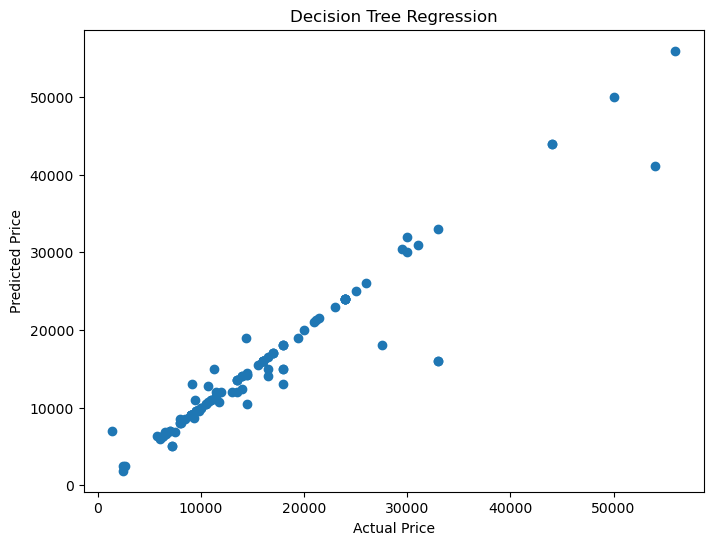

In [292]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(testY, y_pred_dt)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree Regression")
plt.show()

### Feature Importance

In [293]:
feature_names = trainDf.drop("Prize", axis=1).columns

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
4,Front Camera,5.962859e-01
2,Battery_,9.780238e-02
9,Brand_Google,8.207818e-02
0,Memory,5.968584e-02
7,Total_camera,4.382804e-02
8,RAM_Memory,2.940302e-02
6,Mobile Height,2.936569e-02
3,Rear Camera,1.720274e-02
12,Brand_Infinix,1.305230e-02
22,Brand_SAMSUNG,8.881069e-03


### Insight:
The Decision Tree feature importance analysis shows that the Front Camera is the most influential factor in predicting mobile phone prices, contributing approximately 59.63% of the total importance. Battery capacity (9.78%), Google brand (8.21%), and Memory (5.97%) are also major contributors. Engineered features such as Total_camera and RAM_Memory further improved the model's predictive capability. Features such as AI Lens and several brand variables had minimal or no impact on price prediction. Additionally, duplicate brand categories (e.g., REDMI, Redmi, redmi) indicate inconsistent categorical values in the original dataset, suggesting that further preprocessing would improve data quality.